# Chapter 28 — Tensors and Batch Shapes

Chapters 25 through 27 introduced vectors, matrices, and matrix multiplication.

This chapter introduces **tensors**, the general numerical containers used throughout language models.

The central skill is not merely reading shape sizes, but naming what every axis means.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain what a tensor is.
2. Describe scalars, vectors, and matrices as tensors of different ranks.
3. Read a tensor shape and explain every axis.
4. Build nested lists for token IDs, targets, embeddings, attention scores, and logits.
5. Check that nested lists are regular rather than ragged.
6. Convert nested lists into NumPy arrays.
7. Use `.shape`, `.ndim`, indexing, and slicing.
8. Draw 3D and 4D tensors as collections of labeled tables.
9. Check alignment between inputs, targets, embeddings, attention scores, and logits.
10. Explain why shape is part of the data's meaning.

## Tensor, rank, axis, and shape

A **tensor** is a regular numerical array with zero or more axes.

A scalar is a rank-0 tensor, a vector is rank 1, and a matrix is rank 2.

The tensor's **rank** is its number of axes, while its **shape** gives the size of each axis.

Some explanations use “number of dimensions” for rank, but that phrase can be confused with an axis size such as embedding dimension.

This chapter will use **rank** when counting axes.

Examples by rank:

- scalar: shape `()` and rank 0;
- vector: shape `(3,)` and rank 1;
- matrix: shape `(2, 3)` and rank 2;
- stacked matrices: shape `(2, 2, 3)` and rank 3.

The comma in `(3,)` is how Python writes a one-item tuple.

In [1]:
scalar = 3.5
vector = [2.0, -1.0, 3.5]
matrix = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0, 6.0],
]
three_dimensional_tensor = [
    [
        [1.0, 2.0, 3.0],
        [4.0, 5.0, 6.0],
    ],
    [
        [7.0, 8.0, 9.0],
        [10.0, 11.0, 12.0],
    ],
]

print("Scalar:", scalar)
print("Vector:", vector)
print("Matrix:", matrix)
print("Three-dimensional tensor:", three_dimensional_tensor)

Scalar: 3.5
Vector: [2.0, -1.0, 3.5]
Matrix: [[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]
Three-dimensional tensor: [[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]], [[7.0, 8.0, 9.0], [10.0, 11.0, 12.0]]]


The rank-3 example can be viewed as two matrices, each with two rows and three columns.

This stacked-table view will help us interpret higher-rank model data.

## Find the shape of a regular nested list

Before using NumPy, a recursive helper can inspect a nested list.

At every level, it checks that all children have the same shape.

In [2]:
def get_nested_list_shape(nested_object: object) -> tuple[int, ...]:
    if not isinstance(nested_object, list):
        return ()

    if len(nested_object) == 0:
        return (0,)

    first_child_shape = get_nested_list_shape(nested_object[0])

    for child in nested_object:
        child_shape = get_nested_list_shape(child)

        if child_shape != first_child_shape:
            raise ValueError("Nested list is ragged rather than rectangular.")

    return (len(nested_object),) + first_child_shape

In [3]:
named_objects = [
    ("scalar", scalar),
    ("vector", vector),
    ("matrix", matrix),
    ("rank-3 tensor", three_dimensional_tensor),
]

for name, nested_object in named_objects:
    shape = get_nested_list_shape(nested_object)
    print(f"{name:>13}: shape={shape}, rank={len(shape)}")

       scalar: shape=(), rank=0
       vector: shape=(3,), rank=1
       matrix: shape=(2, 3), rank=2
rank-3 tensor: shape=(2, 2, 3), rank=3


For a scalar, the helper returns an empty shape tuple because no axis exists.

For each list level, one axis size is added to the shape.

### Ragged lists do not have one regular tensor shape

Different child lengths make an axis size ambiguous.

In [4]:
ragged_nested_list = [
    [1.0, 2.0, 3.0],
    [4.0, 5.0],
]

try:
    get_nested_list_shape(ragged_nested_list)
except ValueError as error:
    print("Caught expected error:")
    print(error)

Caught expected error:
Nested list is ragged rather than rectangular.


Language-model tensors require regular sizes along every axis, so catching ragged structures early prevents confusing later failures.

## Shape sizes need axis meanings

The shape `(2, 4)` says only that axis 0 has size 2 and axis 1 has size 4.

It could represent two examples by four positions, two attention heads by four positions, or another arrangement entirely.

A useful shape description names every axis.

In [5]:
def print_named_shape(
    name: str,
    shape: tuple[int, ...],
    axis_meanings: tuple[str, ...],
) -> None:
    if len(shape) != len(axis_meanings):
        raise ValueError(
            f"{name} has rank {len(shape)}, but received "
            f"{len(axis_meanings)} axis meanings."
        )

    print(name)
    print("  shape:", shape)
    print("  rank: ", len(shape))

    for axis_index, (axis_size, meaning) in enumerate(
        zip(shape, axis_meanings, strict=True)
    ):
        print(f"  axis {axis_index}: size {axis_size} = {meaning}")

## Token IDs and targets are rank-2 tensors

A token-ID batch usually has shape `batch size × context length`.

We will use a toy vocabulary of size 5, so every token ID and target ID is between 0 and 4.

In [6]:
vocabulary_size = 5

input_token_ids = [
    [0, 1, 2, 3],
    [0, 2, 3, 4],
]
target_token_ids = [
    [1, 2, 3, 4],
    [2, 3, 4, 1],
]

input_shape = get_nested_list_shape(input_token_ids)
target_shape = get_nested_list_shape(target_token_ids)

print_named_shape(
    "input token IDs",
    input_shape,
    ("batch examples", "token positions"),
)
print()
print_named_shape(
    "target token IDs",
    target_shape,
    ("batch examples", "correct-next-token positions"),
)

input token IDs
  shape: (2, 4)
  rank:  2
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions

target token IDs
  shape: (2, 4)
  rank:  2
  axis 0: size 2 = batch examples
  axis 1: size 4 = correct-next-token positions


The two tensors share shape `(2, 4)`, but they play different roles.

Inputs are given to the model, while targets identify the correct next token at each corresponding position.

In [7]:
batch_index = 1
position_index = 2

print("Input ID at batch 1, position 2:")
print(input_token_ids[batch_index][position_index])

print("Target ID at batch 1, position 2:")
print(target_token_ids[batch_index][position_index])

Input ID at batch 1, position 2:
3
Target ID at batch 1, position 2:
4


The first index answers “which example?” and the second answers “which token position?”

## Embeddings are rank-3 tensors

Each token position receives an embedding vector.

For batch size 2, context length 4, and embedding dimension 3, the embedding tensor has shape `(2, 4, 3)`.

In [8]:
embeddings = [
    [
        [0.10, 0.20, 0.30],
        [0.40, 0.50, 0.60],
        [0.70, 0.80, 0.90],
        [1.00, 1.10, 1.20],
    ],
    [
        [1.30, 1.40, 1.50],
        [1.60, 1.70, 1.80],
        [1.90, 2.00, 2.10],
        [2.20, 2.30, 2.40],
    ],
]

embedding_shape = get_nested_list_shape(embeddings)

print_named_shape(
    "embeddings",
    embedding_shape,
    ("batch examples", "token positions", "embedding coordinates"),
)

embeddings
  shape: (2, 4, 3)
  rank:  3
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions
  axis 2: size 3 = embedding coordinates


Each batch example is one `context length × embedding dimension` table.

The rank-3 tensor is therefore a stack of two `4 × 3` matrices.

In [9]:
def print_3d_tensor_as_tables(
    tensor: list[list[list[float]]],
    table_axis_name: str,
) -> None:
    shape = get_nested_list_shape(tensor)

    if len(shape) != 3:
        raise ValueError("Expected a rank-3 tensor.")

    table_count, row_count, _ = shape

    print("Shape:", shape)

    for table_index in range(table_count):
        print()
        print(f"{table_axis_name} {table_index}")
        print("-" * 36)

        for row_index in range(row_count):
            print(tensor[table_index][row_index])


print_3d_tensor_as_tables(embeddings, "batch example")

Shape: (2, 4, 3)

batch example 0
------------------------------------
[0.1, 0.2, 0.3]
[0.4, 0.5, 0.6]
[0.7, 0.8, 0.9]
[1.0, 1.1, 1.2]

batch example 1
------------------------------------
[1.3, 1.4, 1.5]
[1.6, 1.7, 1.8]
[1.9, 2.0, 2.1]
[2.2, 2.3, 2.4]


### Index one embedding coordinate

Three indexes select the example, token position, and embedding coordinate in that order.

In [10]:
batch_index = 1
position_index = 2
embedding_coordinate_index = 0

embedding_value = embeddings[batch_index][position_index][embedding_coordinate_index]

print("Selected embedding value:", embedding_value)
print("Batch example:", batch_index)
print("Token position:", position_index)
print("Embedding coordinate:", embedding_coordinate_index)

Selected embedding value: 1.9
Batch example: 1
Token position: 2
Embedding coordinate: 0


## Attention scores are often rank-4 tensors

Multi-head self-attention scores often have shape `batch size × heads × query positions × key positions`.

For self-attention, the query and key position counts are commonly both equal to context length.

Our toy tensor therefore has shape `(2, 2, 4, 4)`.

In [11]:
attention_scores = [
    [
        [
            [1.0, 0.2, 0.1, 0.0],
            [0.3, 1.1, 0.2, 0.1],
            [0.0, 0.4, 1.2, 0.3],
            [0.1, 0.0, 0.5, 1.3],
        ],
        [
            [0.5, 0.4, 0.3, 0.2],
            [0.1, 0.6, 0.5, 0.4],
            [0.0, 0.2, 0.7, 0.6],
            [0.3, 0.1, 0.2, 0.8],
        ],
    ],
    [
        [
            [1.4, 0.3, 0.2, 0.1],
            [0.2, 1.5, 0.3, 0.2],
            [0.1, 0.3, 1.6, 0.4],
            [0.0, 0.2, 0.4, 1.7],
        ],
        [
            [0.9, 0.1, 0.2, 0.3],
            [0.4, 1.0, 0.1, 0.2],
            [0.3, 0.5, 1.1, 0.1],
            [0.2, 0.3, 0.6, 1.2],
        ],
    ],
]

attention_shape = get_nested_list_shape(attention_scores)

print_named_shape(
    "attention scores",
    attention_shape,
    ("batch examples", "attention heads", "query positions", "key positions"),
)

attention scores
  shape: (2, 2, 4, 4)
  rank:  4
  axis 0: size 2 = batch examples
  axis 1: size 2 = attention heads
  axis 2: size 4 = query positions
  axis 3: size 4 = key positions


For every batch example and head, the final two axes form one `4 × 4` query-by-key table.

The outer two axes organize those tables into batches and heads.

In [12]:
batch_index = 0
head_index = 1
query_position = 2
key_position = 3

selected_attention_score = attention_scores[batch_index][head_index][query_position][
    key_position
]

print("Selected attention score:", selected_attention_score)
print("Batch example:", batch_index)
print("Attention head:", head_index)
print("Query position:", query_position)
print("Key position:", key_position)

Selected attention score: 0.6
Batch example: 0
Attention head: 1
Query position: 2
Key position: 3


These values are illustrative raw scores, not normalized attention probabilities.

## Logits are rank-3 tensors

**Logits** are raw output scores before conversion to probabilities.

Language-model logits usually have shape `batch size × context length × vocabulary size`.

With vocabulary size 5, our logits shape is `(2, 4, 5)`.

In [13]:
logits = [
    [
        [2.0, 0.1, -1.0, 0.5, 1.2],
        [0.3, 1.7, -0.4, 0.2, 0.0],
        [-0.5, 0.6, 2.1, 0.3, -0.2],
        [1.0, -0.1, 0.4, 1.8, 0.2],
    ],
    [
        [1.5, 0.2, -0.7, 0.4, 1.0],
        [0.1, 1.4, -0.3, 0.8, 0.2],
        [-0.4, 0.9, 1.9, 0.1, -0.5],
        [0.7, 0.0, 0.5, 1.6, 0.3],
    ],
]

logits_shape = get_nested_list_shape(logits)

print_named_shape(
    "logits",
    logits_shape,
    ("batch examples", "token positions", "vocabulary-token scores"),
)

logits
  shape: (2, 4, 5)
  rank:  3
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions
  axis 2: size 5 = vocabulary-token scores


Embeddings and logits are both rank 3, but their final axes mean different things.

Embeddings end with learned representation coordinates, while logits end with one score per vocabulary token.

### Select the logit for one correct target

Targets contain one token ID per batch and position.

That ID selects one value from the logits vocabulary axis.

In [14]:
batch_index = 0
position_index = 2
correct_target_token_id = target_token_ids[batch_index][position_index]
logits_for_position = logits[batch_index][position_index]
logit_for_correct_target = logits_for_position[correct_target_token_id]

print("Batch index:", batch_index)
print("Position index:", position_index)
print("Correct target token ID:", correct_target_token_id)
print("Logits for this position:", logits_for_position)
print("Logit for the correct target:", logit_for_correct_target)

assert 0 <= correct_target_token_id < vocabulary_size

Batch index: 0
Position index: 2
Correct target token ID: 3
Logits for this position: [-0.5, 0.6, 2.1, 0.3, -0.2]
Logit for the correct target: 0.3


The target ID is valid because it lies inside the vocabulary axis from 0 through 4.

Later, softmax will turn the five logits into probabilities, and loss will use the probability at this target ID.

## Summarize the core language-model shapes

The following report keeps shape sizes and axis meanings together.

In [15]:
shape_descriptions = [
    (
        "input token IDs",
        get_nested_list_shape(input_token_ids),
        ("batch examples", "token positions"),
    ),
    (
        "target token IDs",
        get_nested_list_shape(target_token_ids),
        ("batch examples", "correct-next-token positions"),
    ),
    (
        "embeddings",
        get_nested_list_shape(embeddings),
        ("batch examples", "token positions", "embedding coordinates"),
    ),
    (
        "attention scores",
        get_nested_list_shape(attention_scores),
        ("batch examples", "attention heads", "query positions", "key positions"),
    ),
    (
        "logits",
        get_nested_list_shape(logits),
        ("batch examples", "token positions", "vocabulary-token scores"),
    ),
]

for name, shape, axis_meanings in shape_descriptions:
    print_named_shape(name, shape, axis_meanings)
    print()

input token IDs
  shape: (2, 4)
  rank:  2
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions

target token IDs
  shape: (2, 4)
  rank:  2
  axis 0: size 2 = batch examples
  axis 1: size 4 = correct-next-token positions

embeddings
  shape: (2, 4, 3)
  rank:  3
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions
  axis 2: size 3 = embedding coordinates

attention scores
  shape: (2, 2, 4, 4)
  rank:  4
  axis 0: size 2 = batch examples
  axis 1: size 2 = attention heads
  axis 2: size 4 = query positions
  axis 3: size 4 = key positions

logits
  shape: (2, 4, 5)
  rank:  3
  axis 0: size 2 = batch examples
  axis 1: size 4 = token positions
  axis 2: size 5 = vocabulary-token scores



This report is more useful than a bare list of shape tuples because every axis has a named role.

## Check relationships between tensor shapes

Input and target token IDs should have the same batch and context shape when there is one target per input position.

Embeddings and logits should share those same first two axes.

Attention should share the batch size and use context length for both query and key axes in this self-attention example.

In [16]:
def assert_language_model_shapes(
    input_shape: tuple[int, ...],
    target_shape: tuple[int, ...],
    embedding_shape: tuple[int, ...],
    attention_shape: tuple[int, ...],
    logits_shape: tuple[int, ...],
) -> None:
    if len(input_shape) != 2 or len(target_shape) != 2:
        raise ValueError("Input and target token IDs must both have rank 2.")

    if len(embedding_shape) != 3:
        raise ValueError("Embeddings must have rank 3.")

    if len(attention_shape) != 4:
        raise ValueError("Attention scores must have rank 4.")

    if len(logits_shape) != 3:
        raise ValueError("Logits must have rank 3.")

    if input_shape != target_shape:
        raise ValueError(
            f"Input shape {input_shape} does not match target shape {target_shape}."
        )

    batch_size, context_length = input_shape

    if embedding_shape[:2] != input_shape:
        raise ValueError("Embedding batch and context axes do not match inputs.")

    if logits_shape[:2] != target_shape:
        raise ValueError("Logits batch and context axes do not match targets.")

    expected_attention_prefix_and_positions = (
        batch_size,
        context_length,
        context_length,
    )
    actual_attention_prefix_and_positions = (
        attention_shape[0],
        attention_shape[2],
        attention_shape[3],
    )

    if actual_attention_prefix_and_positions != expected_attention_prefix_and_positions:
        raise ValueError("Attention batch or position axes do not match inputs.")

In [17]:
assert_language_model_shapes(
    input_shape=get_nested_list_shape(input_token_ids),
    target_shape=get_nested_list_shape(target_token_ids),
    embedding_shape=get_nested_list_shape(embeddings),
    attention_shape=get_nested_list_shape(attention_scores),
    logits_shape=get_nested_list_shape(logits),
)

print("All related tensor axes align.")

All related tensor axes align.


The tensors do not all need identical shapes.

They need the axes that refer to the same concepts to agree.

### Catch a target-shape mismatch

A `(2, 3)` target tensor cannot provide one target for every position in `(2, 4)` inputs.

In [18]:
bad_target_token_ids = [
    [1, 2, 3],
    [2, 3, 4],
]

try:
    assert_language_model_shapes(
        input_shape=get_nested_list_shape(input_token_ids),
        target_shape=get_nested_list_shape(bad_target_token_ids),
        embedding_shape=get_nested_list_shape(embeddings),
        attention_shape=get_nested_list_shape(attention_scores),
        logits_shape=get_nested_list_shape(logits),
    )
except ValueError as error:
    print("Caught expected error:")
    print(error)

Caught expected error:
Input shape (2, 4) does not match target shape (2, 3).


Shape checks turn a conceptual mismatch into an immediate, readable error.

## Convert nested lists to NumPy arrays

NumPy stores regular numerical tensors compactly and exposes their shapes directly.

The `.ndim` attribute reports rank, and `.shape` reports every axis size.

In [19]:
import numpy as np

scalar_array = np.array(scalar)
vector_array = np.array(vector)
matrix_array = np.array(matrix)
input_token_ids_array = np.array(input_token_ids)
target_token_ids_array = np.array(target_token_ids)
embeddings_array = np.array(embeddings)
attention_scores_array = np.array(attention_scores)
logits_array = np.array(logits)

named_arrays = [
    ("scalar", scalar_array),
    ("vector", vector_array),
    ("matrix", matrix_array),
    ("input token IDs", input_token_ids_array),
    ("target token IDs", target_token_ids_array),
    ("embeddings", embeddings_array),
    ("attention scores", attention_scores_array),
    ("logits", logits_array),
]

for name, array in named_arrays:
    print(f"{name:>18}: shape={array.shape}, rank={array.ndim}, dtype={array.dtype}")

            scalar: shape=(), rank=0, dtype=float64
            vector: shape=(3,), rank=1, dtype=float64
            matrix: shape=(2, 3), rank=2, dtype=float64
   input token IDs: shape=(2, 4), rank=2, dtype=int64
  target token IDs: shape=(2, 4), rank=2, dtype=int64
        embeddings: shape=(2, 4, 3), rank=3, dtype=float64
  attention scores: shape=(2, 2, 4, 4), rank=4, dtype=float64
            logits: shape=(2, 4, 5), rank=3, dtype=float64


Token IDs use an integer data type, while embeddings, attention scores, and logits use floating-point values.

Shape describes axis sizes; data type describes the kind of value stored in each entry.

## NumPy indexing follows the same axis order

NumPy combines nested indexes with commas but preserves every axis meaning.

In [20]:
batch_index = 1
position_index = 2
embedding_coordinate_index = 0

value_from_list = embeddings[batch_index][position_index][embedding_coordinate_index]
value_from_array = embeddings_array[
    batch_index,
    position_index,
    embedding_coordinate_index,
]

print("Nested-list value:", value_from_list)
print("NumPy value:", value_from_array)
print("Values match:", value_from_list == value_from_array)

Nested-list value: 1.9
NumPy value: 1.9
Values match: True


## NumPy slices select whole axis regions

A colon means “take every entry along this axis.”

Selecting one batch and one position while keeping all embedding coordinates returns one embedding vector.

In [21]:
selected_embedding = embeddings_array[0, 1, :]
selected_example_embeddings = embeddings_array[0, :, :]
selected_attention_table = attention_scores_array[0, 1, :, :]

print("One embedding shape:", selected_embedding.shape)
print("One example's embedding table shape:", selected_example_embeddings.shape)
print("One attention table shape:", selected_attention_table.shape)

One embedding shape: (3,)
One example's embedding table shape: (4, 3)
One attention table shape: (4, 4)


Selecting one integer index removes that axis from the result.

Keeping an axis with `:` preserves it.

## Draw tensors as collections of tables

A rank-3 tensor can be viewed as a stack of matrices.

A rank-4 attention tensor can be viewed as a grid of matrices indexed by batch example and head.

The composite figure shows both views with explicit labels.

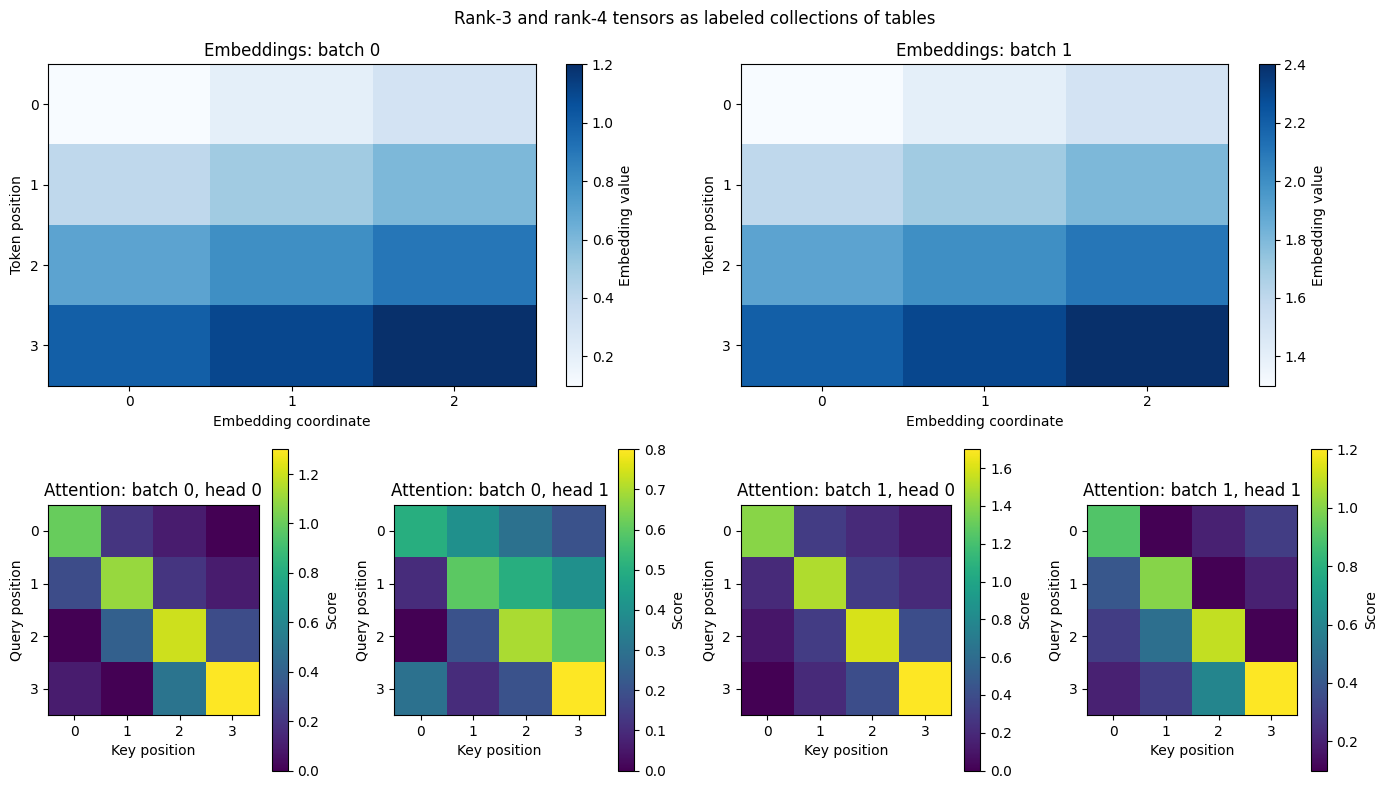

In [22]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(14, 8))
grid = figure.add_gridspec(2, 4)

embedding_axes = [
    figure.add_subplot(grid[0, 0:2]),
    figure.add_subplot(grid[0, 2:4]),
]

for batch_index, axes in enumerate(embedding_axes):
    image = axes.imshow(embeddings_array[batch_index], aspect="auto", cmap="Blues")
    axes.set_title(f"Embeddings: batch {batch_index}")
    axes.set_xlabel("Embedding coordinate")
    axes.set_ylabel("Token position")
    axes.set_xticks(range(embedding_shape[2]))
    axes.set_yticks(range(embedding_shape[1]))
    figure.colorbar(image, ax=axes, label="Embedding value")

attention_axes = []

for batch_index in range(attention_shape[0]):
    for head_index in range(attention_shape[1]):
        column_index = batch_index * attention_shape[1] + head_index
        axes = figure.add_subplot(grid[1, column_index])
        attention_axes.append(axes)
        image = axes.imshow(
            attention_scores_array[batch_index, head_index],
            aspect="equal",
            cmap="viridis",
        )
        axes.set_title(f"Attention: batch {batch_index}, head {head_index}")
        axes.set_xlabel("Key position")
        axes.set_ylabel("Query position")
        axes.set_xticks(range(attention_shape[3]))
        axes.set_yticks(range(attention_shape[2]))
        figure.colorbar(image, ax=axes, label="Score")

figure.suptitle("Rank-3 and rank-4 tensors as labeled collections of tables")
plt.tight_layout()
plt.show()

The top row contains two embedding matrices selected by the batch axis.

The bottom row contains four attention matrices selected by both batch and head axes.

The visualization works because fixing the outer axes leaves a two-dimensional table.

## Print shapes constantly

Shape reporting is a debugging habit, not decorative output.

It confirms both rank and axis sizes at each transformation boundary.

In [23]:
print("Language-model tensor shapes")
print("-" * 72)
print("input token IDs: ", input_token_ids_array.shape, "batch × context")
print("target token IDs:", target_token_ids_array.shape, "batch × context")
print("embeddings:      ", embeddings_array.shape, "batch × context × embedding")
print(
    "attention scores:",
    attention_scores_array.shape,
    "batch × heads × query × key",
)
print("logits:          ", logits_array.shape, "batch × context × vocabulary")

Language-model tensor shapes
------------------------------------------------------------------------
input token IDs:  (2, 4) batch × context
target token IDs: (2, 4) batch × context
embeddings:       (2, 4, 3) batch × context × embedding
attention scores: (2, 2, 4, 4) batch × heads × query × key
logits:           (2, 4, 5) batch × context × vocabulary


## A clean tensor-shape pipeline

The final pipeline validates related axes, converts every object to NumPy, and verifies the expected shapes.

In [24]:
expected_shapes = {
    "input token IDs": (2, 4),
    "target token IDs": (2, 4),
    "embeddings": (2, 4, 3),
    "attention scores": (2, 2, 4, 4),
    "logits": (2, 4, 5),
}

actual_arrays = {
    "input token IDs": input_token_ids_array,
    "target token IDs": target_token_ids_array,
    "embeddings": embeddings_array,
    "attention scores": attention_scores_array,
    "logits": logits_array,
}

assert_language_model_shapes(
    input_shape=input_token_ids_array.shape,
    target_shape=target_token_ids_array.shape,
    embedding_shape=embeddings_array.shape,
    attention_shape=attention_scores_array.shape,
    logits_shape=logits_array.shape,
)

print("Tensor pipeline summary")
print("-" * 64)

for name, expected_shape in expected_shapes.items():
    actual_shape = actual_arrays[name].shape
    print(f"{name:<18} expected={expected_shape} actual={actual_shape}")
    assert actual_shape == expected_shape

print("All expected shapes and related axes are valid.")

Tensor pipeline summary
----------------------------------------------------------------
input token IDs    expected=(2, 4) actual=(2, 4)
target token IDs   expected=(2, 4) actual=(2, 4)
embeddings         expected=(2, 4, 3) actual=(2, 4, 3)
attention scores   expected=(2, 2, 4, 4) actual=(2, 2, 4, 4)
logits             expected=(2, 4, 5) actual=(2, 4, 5)
All expected shapes and related axes are valid.


## What not to do

- Do not treat shape as a minor implementation detail.
- Do not use “dimension” without clarifying whether you mean tensor rank or an axis size.
- Do not confuse batch size, context length, embedding dimension, head count, and vocabulary size.
- Do not assume equal shapes imply equal meanings.
- Do not require related tensors to have identical shapes when only selected axes should align.
- Do not index a logits vocabulary axis with a target ID outside its valid range.
- Do not ignore ragged nested lists or shape mismatch errors.

## Gotchas

A scalar is rank 0, a vector is rank 1, and a matrix is rank 2.

Token IDs and targets are commonly shaped `batch × context`.

Embeddings and logits are both rank 3, but their final axes mean embedding coordinates and vocabulary scores respectively.

Multi-head self-attention scores are commonly shaped `batch × heads × query positions × key positions`.

Selecting an integer index removes an axis, while selecting with `:` keeps it.

Shape checks should compare the axes that represent the same concepts.

## Takeaways

A tensor is a regular numerical array whose rank counts axes and whose shape gives every axis size.

Language models commonly use token IDs shaped `batch × context`, embeddings shaped `batch × context × embedding`, attention scores shaped `batch × heads × query × key`, and logits shaped `batch × context × vocabulary`.

Shape is part of meaning because every axis answers a specific question about the data.

Good tensor code names axes, prints shapes, checks related dimensions, and treats shape errors as conceptual clues.

## What comes next

The next chapter studies NumPy arrays more systematically.

We will build on these tensor shapes to practice array creation, indexing, slicing, reshaping, and basic numerical operations.